In [6]:
import pandas as pd

def smooth_features(features, window_size=6):
    """
    Applies a rolling mean to features to stabilize HMM states.
    window_size=6 represents a 30-second moving average (6 * 5s).
    """
    df = pd.DataFrame(features)
    # Use Gaussian or simple rolling mean to reduce flicker
    smoothed = df.rolling(window=window_size, min_periods=1, center=True).mean()
    return smoothed.values

In [1]:
import numpy as np
from scipy.signal import welch
from antropy import perm_entropy

# Left↔Right homologous bipolar pairs (0-based indices) based on EDF channel list
# Left (1–8) pairs with Right (9–16 / 13–16) as appropriate:
PAIRS_LR = [
    (0, 12),  # ch1  FP1-F7  ↔ ch13 FP2-F8
    (1, 13),  # ch2  F7-T7   ↔ ch14 F8-T8
    (2, 14),  # ch3  T7-P7   ↔ ch15 T8-P8
    (3, 15),  # ch4  P7-O1   ↔ ch16 P8-O2
    (4, 8),   # ch5  FP1-F3  ↔ ch9  FP2-F4
    (5, 9),   # ch6  F3-C3   ↔ ch10 F4-C4
    (6, 10),  # ch7  C3-P3   ↔ ch11 C4-P4
    (7, 11),  # ch8  P3-O1   ↔ ch12 P4-O2
]

def get_advanced_state_features(epoch_data, sfreq=256):
    """
    Transforms 5-second EEG windows into a 6D state-space coordinate:
    1. Theta/Alpha Ratio
    2. Permutation Entropy
    3. Hemispheric Synchronization
    4. Line Length (Spikiness)
    5. RMS Amplitude (Power)
    6. Spectral Edge Frequency 95%
    """
    features = []
    eps = 1e-10

    for window in epoch_data:
        # Use primary 18 channels to avoid redundant data
        X = window[0:18, :]

        # 1) SPECTRAL RATIO: Energy-based Theta/Alpha ratio
        freqs, psd = welch(X, sfreq, nperseg=sfreq * 2)
        th_mask = (freqs >= 4) & (freqs < 8)
        al_mask = (freqs >= 8) & (freqs < 13)
        theta = np.trapezoid(psd[:, th_mask], freqs[th_mask], axis=1).mean()
        alpha = np.trapezoid(psd[:, al_mask], freqs[al_mask], axis=1).mean()
        ta_ratio = theta / (alpha + eps)

        # 2) COMPLEXITY: Permutation Entropy
        complexity = np.mean([perm_entropy(ch, order=4, delay=1, normalize=True) for ch in X])

        # 3) SYNCHRONIZATION: Mean Correlation over homologous pairs
        sync_scores = [np.corrcoef(window[li], window[ri])[0, 1] for li, ri in PAIRS_LR]
        avg_sync = np.nanmean(sync_scores)

        # 4) LINE LENGTH: Total vertical distance (measures 'spikiness')
        line_length = np.mean(np.sum(np.abs(np.diff(X, axis=1)), axis=1))

        # 5) RMS AMPLITUDE: Root Mean Square (measures signal 'loudness')
        rms = np.mean(np.sqrt(np.mean(X**2, axis=1)))

        # 6) SPECTRAL EDGE FREQUENCY (95%): Frequency below which 95% power sits
        df = np.diff(freqs)
        df = np.r_[df, df[-1]]                 # match length to freqs
        power_bins = psd * df                  # convert PSD (per Hz) -> power per bin
        cumulative_power = np.cumsum(power_bins, axis=1)
        total_power = cumulative_power[:, -1]
        sef_indices = np.argmax(cumulative_power >= 0.95 * total_power[:, None], axis=1)
        avg_sef95 = freqs[sef_indices].mean()


        features.append([ta_ratio, complexity, avg_sync, line_length, rms, avg_sef95])

    return np.array(features)

## Epoching of the Patient 1 data  
Split the edfs into 5 minute chunks. Each edf is 1-hour long. We choose 01.edf for the baseline data and 03.edf for the data with seizure.

In [23]:
import mne
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from hmmlearn import hmm

# 1. Define a list of training files (mix of baseline and seizure)
train_files = [
    {"path": "chb-mit-scalp-eeg-database-1.0.0/chb01/chb01_01.edf", "is_seiz": False},
    {"path": "chb-mit-scalp-eeg-database-1.0.0/chb01/chb01_02.edf", "is_seiz": False},
    {"path": "chb-mit-scalp-eeg-database-1.0.0/chb01/chb01_03.edf", "is_seiz": True},
    {"path": "chb-mit-scalp-eeg-database-1.0.0/chb01/chb01_04.edf", "is_seiz": True}
]

all_features = []
lengths = [] # Important for HMM training on multiple sequences

for f_info in train_files:
    # Load and clean
    raw = mne.io.read_raw_edf(f_info["path"], preload=True, verbose=False)
    raw.rename_channels(lambda x: x.strip('.'))
    
    # Epoch into 5s windows
    events = mne.make_fixed_length_events(raw, duration=5.0)
    epochs = mne.Epochs(raw, events, tmin=0, tmax=5.0, baseline=None, preload=True, verbose=False)
    data = epochs.get_data()
    
    # Extract features (using your get_advanced_state_features function)
    feats = get_advanced_state_features(data)
    
    all_features.append(feats)
    lengths.append(len(feats))

print("Loading complete")

/var/folders/zf/_1h962cx0q3dj615fqjpj7bw0000gn/T/ipykernel_67196/2358028234.py:20: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(f_info["path"], preload=True, verbose=False)
/var/folders/zf/_1h962cx0q3dj615fqjpj7bw0000gn/T/ipykernel_67196/2358028234.py:20: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(f_info["path"], preload=True, verbose=False)
/var/folders/zf/_1h962cx0q3dj615fqjpj7bw0000gn/T/ipykernel_67196/2358028234.py:20: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(f_info["path"], preload=True, verbose=False)
/var/folders/zf/_1h962cx0q3dj615fqjpj7bw0000gn/T/ipykernel_67196/2358028234.py:20: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying r

Loading complete


In [10]:
### Should remove this

# 2. Combine and Scale
feat_stack = np.vstack(all_features)
scaler = StandardScaler()
feat_scaled = scaler.fit_transform(feat_stack)

# 3. PCA
pca = PCA(n_components=3)
obs_for_hmm = pca.fit_transform(feat_scaled)

# 4. HMM Fit with 'lengths' parameter
# This tells the HMM where one recording ends and another begins
model = hmm.GaussianHMM(n_components=3, covariance_type="full", n_iter=1000, random_state=42)
model.fit(obs_for_hmm, lengths=lengths)

# Smooth

print(f"Model trained on {len(lengths)} files ({sum(lengths)} total windows).")

Model trained on 4 files (2876 total windows).


In [11]:
### Should remove this also

# 1. Smooth the features for each file separately to prevent 'leakage'
smoothed_all_features = [smooth_features(f) for f in all_features]

# 2. Re-combine, Scale, and PCA
feat_stack_smooth = np.vstack(smoothed_all_features)
scaler = StandardScaler()
feat_scaled_smooth = scaler.fit_transform(feat_stack_smooth)

pca = PCA(n_components=3)
obs_for_hmm_smooth = pca.fit_transform(feat_scaled_smooth)

# 3. Re-train HMM with a more 'stubborn' transition prior
# covariance_type="diag" helps prevent overfitting to noise in PCA space
model = hmm.GaussianHMM(
    n_components=3, 
    covariance_type="diag", 
    n_iter=2000, 
    random_state=42
)
model.fit(obs_for_hmm_smooth, lengths=lengths)

print("Smoothed HMM Training Complete.")

Smoothed HMM Training Complete.


In [24]:
from sklearn.preprocessing import StandardScaler

# 1. Scale and Smooth each file INDIVIDUALLY
# This prevents the 'loudness' of File 01 from being compared to File 03
processed_all_features = []

for f_features in all_features:
    # A. Scale this specific file to its own mean/std
    scaler_local = StandardScaler()
    feat_local_scaled = scaler_local.fit_transform(f_features)
    
    # B. Smooth the normalized data
    # (Using your existing smooth_features function)
    feat_local_smoothed = smooth_features(feat_local_scaled, window_size=6)
    
    processed_all_features.append(feat_local_smoothed)

# 2. Re-combine (Stack) and PCA
# We don't need another StandardScaler here because they are already Z-scored
feat_stack_final = np.vstack(processed_all_features)

pca = PCA(n_components=3)
obs_for_hmm_final = pca.fit_transform(feat_stack_final)

# 3. Re-train HMM
model = hmm.GaussianHMM(
    n_components=3, 
    covariance_type="diag", 
    n_iter=2000, 
    random_state=42
)
model.fit(obs_for_hmm_final, lengths=lengths)

print("Properly Scaled & Smoothed HMM Training Complete.")

Properly Scaled & Smoothed HMM Training Complete.


Transition Probability Matrix:
         State 0  State 1  State 2
State 0   0.9595   0.0058   0.0347
State 1   0.0086   0.9798   0.0116
State 2   0.0283   0.0182   0.9534


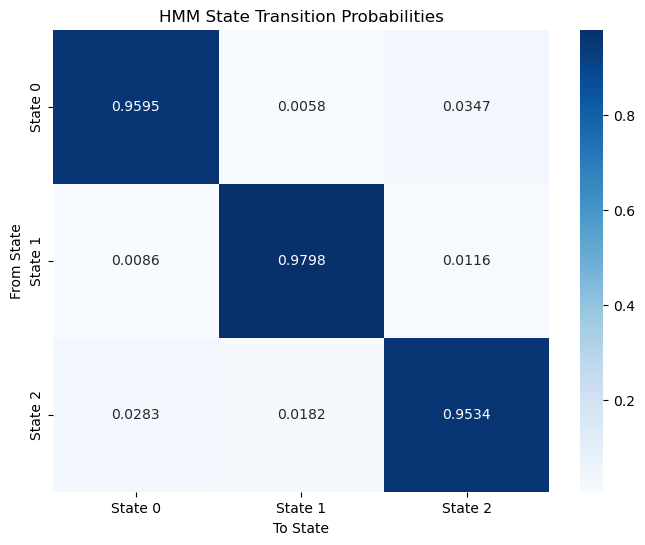

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# The matrix itself
trans_matrix = model.transmat_

# Create a clean DataFrame for viewing
state_labels = ["State 0", "State 1", "State 2"]
df_trans = pd.DataFrame(trans_matrix, columns=state_labels, index=state_labels)

print("Transition Probability Matrix:")
print(df_trans.round(4))

# Heatmap visualization
plt.figure(figsize=(8, 6))
sns.heatmap(df_trans, annot=True, cmap='Blues', fmt='.4f')
plt.title("HMM State Transition Probabilities")
plt.xlabel("To State")
plt.ylabel("From State")
plt.show()

In [20]:
# The model stores the 'average' feature values for each state in .means_
# Our features: [Ratio, Complexity, Sync, Line Length, RMS, SEF95]
# Line Length is index 3.

for i in range(model.n_components):
    # Inverse transform through PCA if needed, or just look at the raw means 
    # if you didn't use PCA. Since we used PCA, we look at the PCA-space means:
    avg_spikiness = model.means_[i][0] # PC1 usually captures the most variance
    print(f"State {i} - PCA Cluster Center (Dim 1): {avg_spikiness:.4f}")

# CLINICAL MAPPING (Typical):
# High Spikiness/Power = Ictal (Seizure)
# High Sync/Lower Complexity = Often Pre-Ictal
# High Complexity/Low Power = Baseline

State 0 - PCA Cluster Center (Dim 1): 1.4710
State 1 - PCA Cluster Center (Dim 1): -1.3061
State 2 - PCA Cluster Center (Dim 1): 0.0583


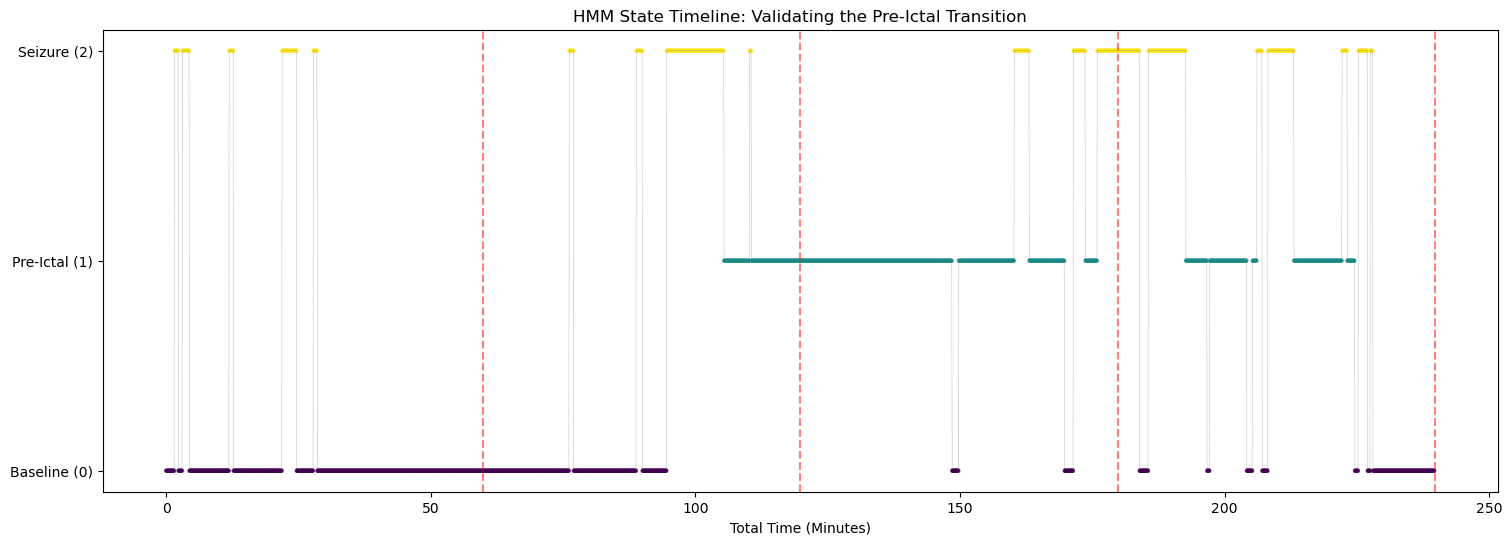

In [21]:
# 1. Predict states for the combined smoothed data
hidden_states = model.predict(obs_for_hmm_smooth)

# 2. Plot the timeline
plt.figure(figsize=(18, 6))
time_axis = np.arange(len(hidden_states)) * 5 / 60  # Minutes

plt.scatter(time_axis, hidden_states, c=hidden_states, cmap='viridis', s=5, alpha=0.5)
plt.plot(time_axis, hidden_states, color='black', linewidth=0.5, alpha=0.2)

# Mark the file boundaries
current_min = 0
for length in lengths:
    current_min += (length * 5 / 60)
    plt.axvline(x=current_min, color='red', linestyle='--', alpha=0.5, label='File Break')

# Mapping for clarity
plt.yticks([0, 1, 2], ['Baseline (0)', 'Pre-Ictal (1)', 'Seizure (2)'])
plt.xlabel('Total Time (Minutes)')
plt.title('HMM State Timeline: Validating the Pre-Ictal Transition')
plt.show()

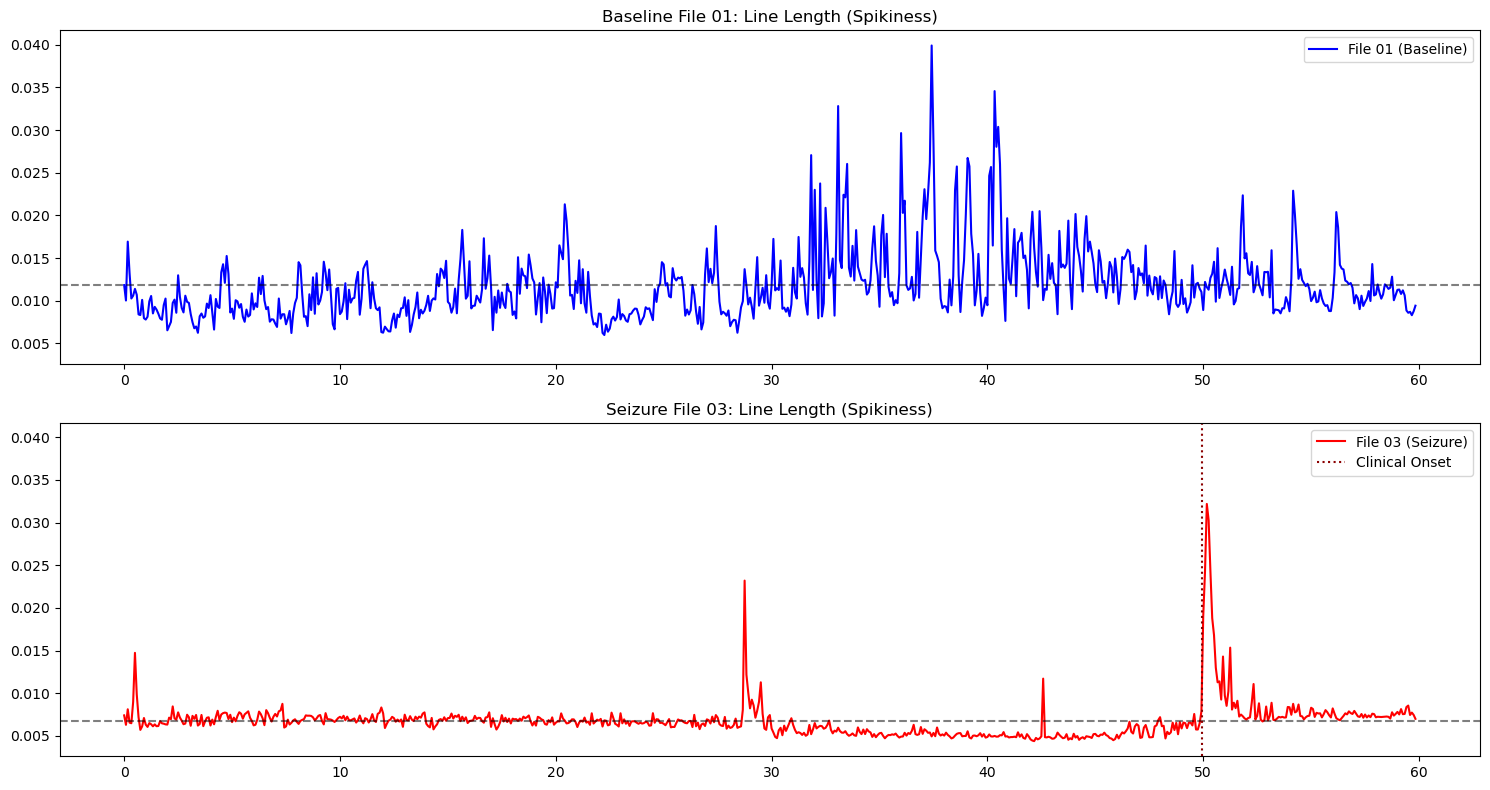

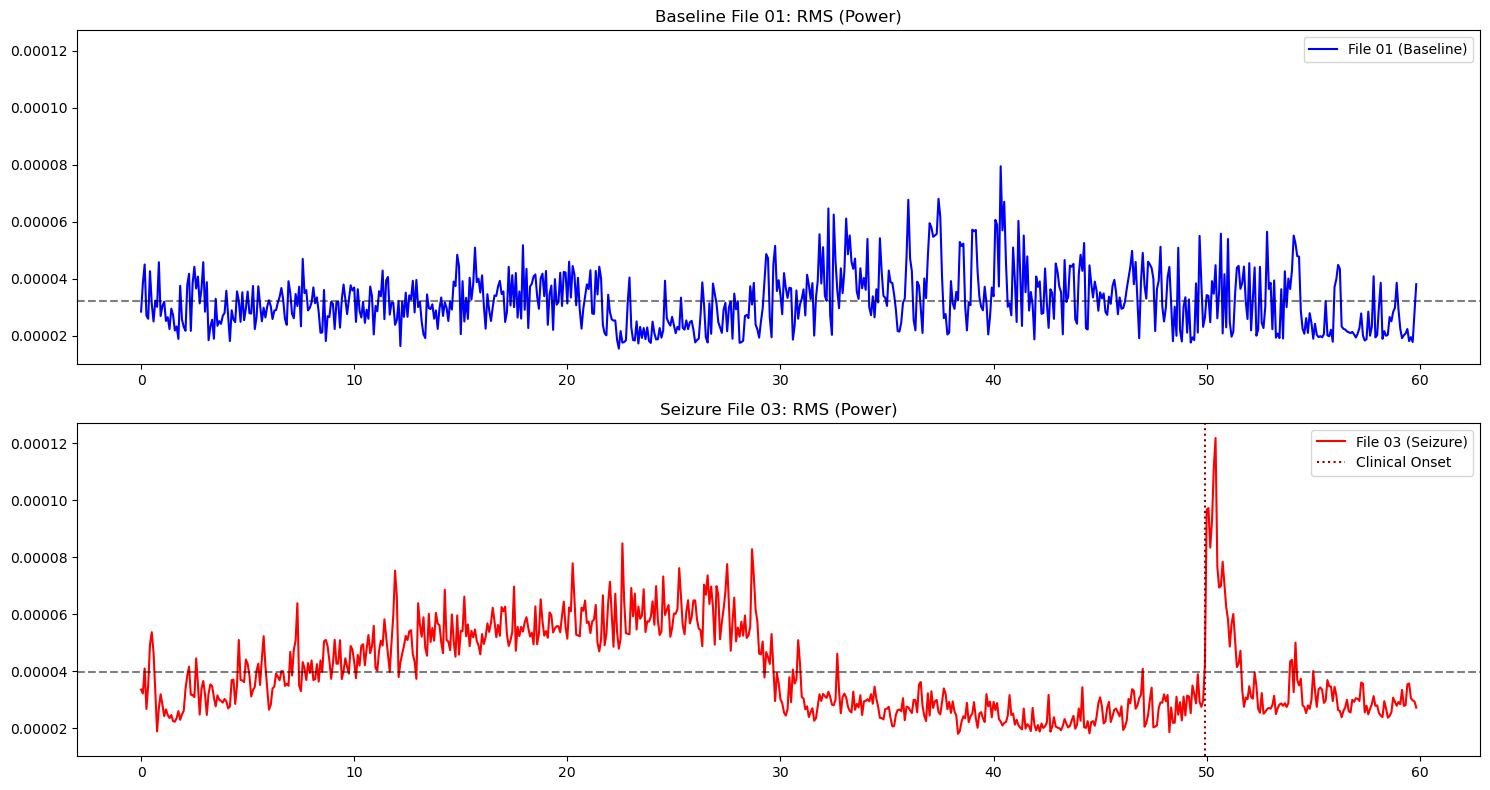

In [30]:
import matplotlib.pyplot as plt

def compare_file_features(feat_1, feat_3, feature_idx=3, label="Line Length"):
    """
    Plots a specific feature from File 1 (Baseline) and File 3 (Seizure) 
    side-by-side to identify scaling issues.
    """
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharey=True)
    
    # File 01: Pure Baseline
    time_1 = np.arange(len(feat_1)) * 5 / 60
    ax1.plot(time_1, feat_1[:, feature_idx], color='blue', label='File 01 (Baseline)')
    ax1.axhline(y=np.mean(feat_1[:, feature_idx]), color='black', linestyle='--', alpha=0.5)
    ax1.set_title(f"Baseline File 01: {label}")
    ax1.legend()

    # File 03: Seizure at 2996s (~50 mins)
    time_3 = np.arange(len(feat_3)) * 5 / 60
    ax2.plot(time_3, feat_3[:, feature_idx], color='red', label='File 03 (Seizure)')
    ax2.axhline(y=np.mean(feat_3[:, feature_idx]), color='black', linestyle='--', alpha=0.5)
    ax2.axvline(x=2996/60, color='darkred', linestyle=':', label='Clinical Onset')
    ax2.set_title(f"Seizure File 03: {label}")
    ax2.legend()

    plt.tight_layout()
    plt.show()

# Compare Line Length (Index 3)
compare_file_features(all_features[0], all_features[2], feature_idx=3, label="Line Length (Spikiness)")

# Compare RMS Power (Index 4)
compare_file_features(all_features[0], all_features[2], feature_idx=4, label="RMS (Power)")

Visualizing Per-File Normalized States...


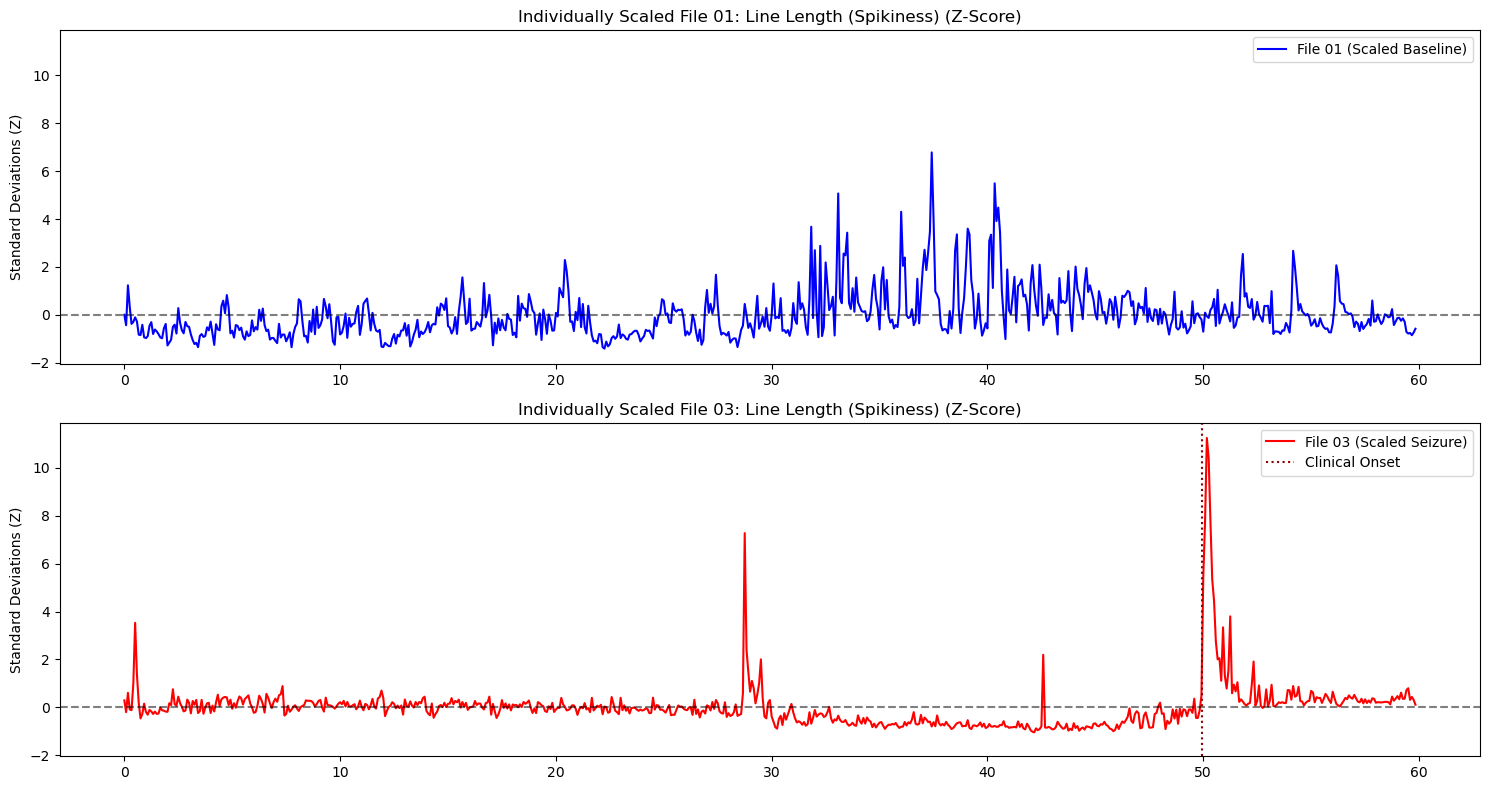

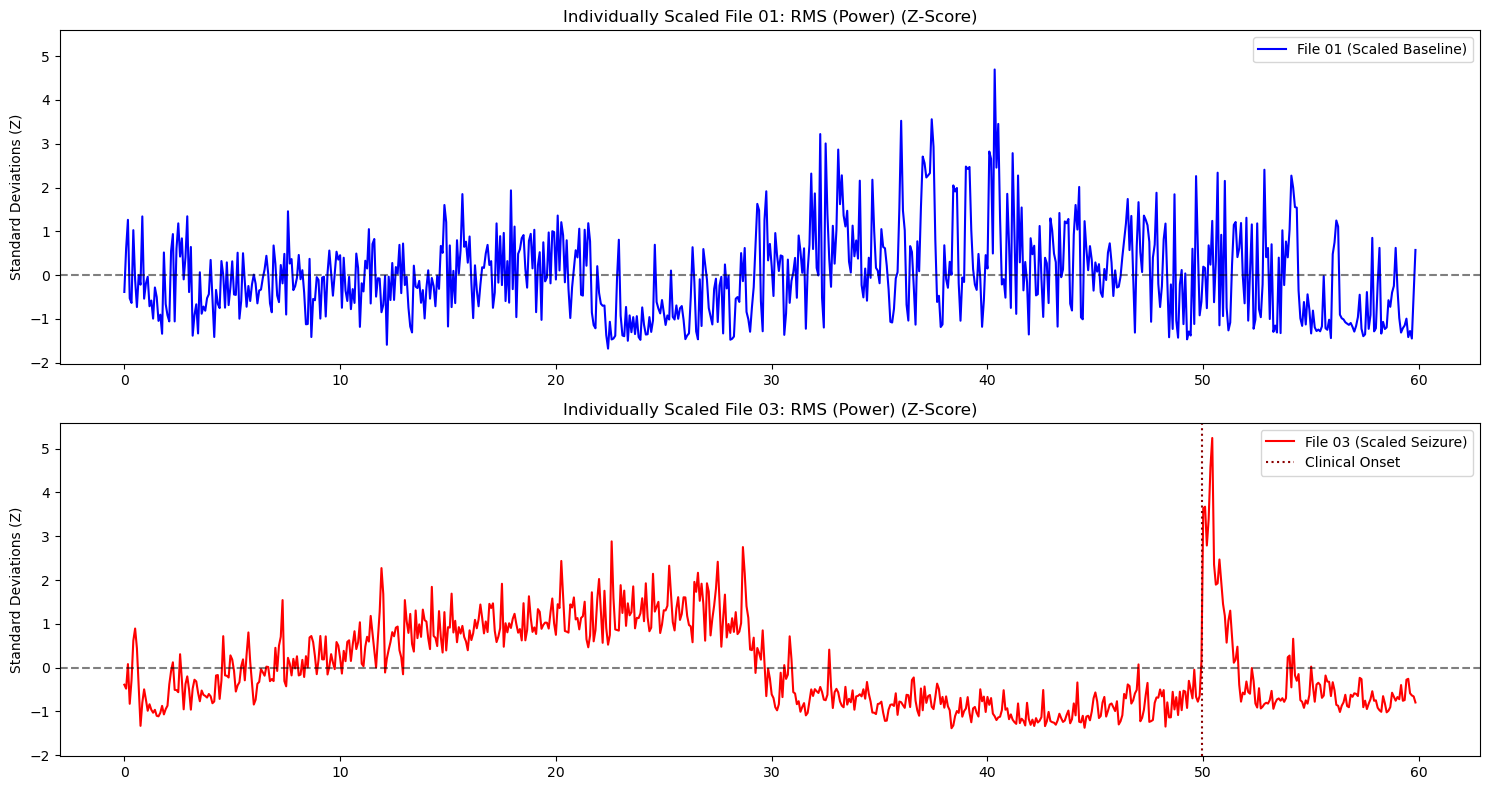

In [22]:
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

def compare_scaled_file_features(feat_1, feat_3, feature_idx=3, label="Line Length"):
    """
    Individually scales File 1 and File 3, then plots them side-by-side.
    This demonstrates what the HMM 'sees' after local normalization.
    """
    # 1. Apply Local Scaling (Z-Score)
    scaler = StandardScaler()
    feat_1_scaled = scaler.fit_transform(feat_1)
    feat_3_scaled = scaler.fit_transform(feat_3)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharey=True)
    
    # File 01: Pure Baseline (Now centered at 0)
    time_1 = np.arange(len(feat_1_scaled)) * 5 / 60
    ax1.plot(time_1, feat_1_scaled[:, feature_idx], color='blue', label='File 01 (Scaled Baseline)')
    ax1.axhline(y=0, color='black', linestyle='--', alpha=0.5) # Mean is now 0
    ax1.set_title(f"Individually Scaled File 01: {label} (Z-Score)")
    ax1.set_ylabel("Standard Deviations (Z)")
    ax1.legend()

    # File 03: Seizure (Now centered at 0, highlighting the relative spike)
    time_3 = np.arange(len(feat_3_scaled)) * 5 / 60
    ax2.plot(time_3, feat_3_scaled[:, feature_idx], color='red', label='File 03 (Scaled Seizure)')
    ax2.axhline(y=0, color='black', linestyle='--', alpha=0.5) # Mean is now 0
    ax2.axvline(x=2996/60, color='darkred', linestyle=':', label='Clinical Onset')
    ax2.set_title(f"Individually Scaled File 03: {label} (Z-Score)")
    ax2.set_ylabel("Standard Deviations (Z)")
    ax2.legend()

    plt.tight_layout()
    plt.show()

# Compare the Normalized features
print("Visualizing Per-File Normalized States...")
compare_scaled_file_features(all_features[0], all_features[2], feature_idx=3, label="Line Length (Spikiness)")
compare_scaled_file_features(all_features[0], all_features[2], feature_idx=4, label="RMS (Power)")

In [31]:
import os
import numpy as np

# hidden_states: the full array of predictions from the HMM
# lengths: list of window counts per file (from your training code)
# train_files: your list of dictionaries containing file metadata

current_idx = 0

print(f"{'Filename':<15} | {'State':<12} | {'Start (sec)':<12} | {'End (sec)':<12}")
print("-" * 60)

for i, length in enumerate(lengths):
    # Slice the global hidden_states for the current file
    file_states = hidden_states[current_idx : current_idx + length]
    
    # Extract filename from path for display
    filename = os.path.basename(train_files[i]["path"])
    
    # Find indices where the state changes
    # np.diff returns non-zero at the index BEFORE a change
    transitions = np.where(np.diff(file_states) != 0)[0] + 1
    
    # Combine with file boundaries (start/end)
    endpoints = np.concatenate(([0], transitions, [length]))
    
    for j in range(len(endpoints) - 1):
        start_win = endpoints[j]
        end_win = endpoints[j+1]
        state = file_states[start_win]
        
        # Convert window index to seconds (5s windows)
        start_sec = start_win * 5
        end_sec = end_win * 5
        
        # Filter for the states we are investigating: Pre-Ictal (1) and Ictal (2)
        if state in [1, 2]:
            state_label = "Pre-Ictal" if state == 1 else "Ictal"
            print(f"{filename:<15} | {state_label:<12} | {start_sec:<12} | {end_sec:<12}")
            
    # Advance the pointer to the next file in the global array
    current_idx += length

Filename        | State        | Start (sec)  | End (sec)   
------------------------------------------------------------
chb01_01.edf    | Ictal        | 95           | 140         
chb01_01.edf    | Ictal        | 185          | 265         
chb01_01.edf    | Ictal        | 715          | 765         
chb01_01.edf    | Ictal        | 1315         | 1480        
chb01_01.edf    | Ictal        | 1670         | 1715        
chb01_02.edf    | Ictal        | 975          | 1025        
chb01_02.edf    | Ictal        | 1735         | 1805        
chb01_02.edf    | Ictal        | 2080         | 2730        
chb01_02.edf    | Pre-Ictal    | 2730         | 3020        
chb01_02.edf    | Ictal        | 3020         | 3040        
chb01_02.edf    | Pre-Ictal    | 3040         | 3595        
chb01_03.edf    | Pre-Ictal    | 0            | 1720        
chb01_03.edf    | Pre-Ictal    | 1795         | 2425        
chb01_03.edf    | Ictal        | 2425         | 2595        
chb01_03.edf    | Pre-Ic